# Notebook 13: Ensemble Strategy - Final Evaluation

## Objetivo
Combinar DeBERTa-v3-large y Llama-3.1-8B mediante soft voting ensemble.

## CRÍTICO: Patrón de Inferencia Secuencial
Para evitar errores CUDA OOM, NUNCA cargamos ambos modelos simultáneamente.

## 1. Imports

In [1]:
import torch
import pandas as pd
import numpy as np
import gc
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import time
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)
from peft import PeftModel

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.11.0.dev20251227+cu128
CUDA: True


## 2. Rutas del Proyecto

In [2]:
def find_root() -> Path:
    current = Path.cwd()
    for cand in [current, *current.parents]:
        if (cand / "data" / "raw").exists():
            return cand
    raise FileNotFoundError("No se encontro data/raw")

PROJECT_ROOT = find_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
BOUNDARIES_DIR = PROJECT_ROOT / "data" / "processed" / "boundaries"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints" / "finetuning"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "ensemble"
REPORTS_DIR = PROJECT_ROOT / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 256

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

PROJECT_ROOT: /home/eeguskiza/DEUSTO/multi-author-analysis
OUTPUT_DIR: /home/eeguskiza/DEUSTO/multi-author-analysis/outputs/ensemble


## 3. Funciones de Carga

In [3]:
def load_sentences(level: str, split: str, doc_id: str) -> list[str]:
    path = DATA_RAW / level / split / f"{doc_id}.txt"
    if not path.exists():
        raise FileNotFoundError(f"No encontrado: {path}")
    text = path.read_text(encoding='utf-8').strip()
    sentences = [s.strip() for s in text.split('\n') if s.strip()]
    return sentences

def create_text_pairs(df: pd.DataFrame, desc: str = "Procesando") -> list[dict]:
    pairs = []
    skipped = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        try:
            sentences = load_sentences(row['level'], row['split'], row['doc_id'])
            if row['sent_left_id'] >= len(sentences) or row['sent_right_id'] >= len(sentences):
                skipped += 1
                continue
            text_a = sentences[row['sent_left_id']]
            text_b = sentences[row['sent_right_id']]
            if not text_a or not text_b:
                skipped += 1
                continue
            pairs.append({
                'text_a': text_a,
                'text_b': text_b,
                'label': int(row['y']),
                'level': row['level'],
                'doc_id': row['doc_id']
            })
        except Exception as e:
            skipped += 1
    if skipped > 0:
        print(f"Saltados: {skipped}")
    return pairs

print("Funciones OK")

Funciones OK


## 4. Cargar Datos

In [4]:
boundaries_val = pd.read_csv(BOUNDARIES_DIR / "boundaries_validation.csv")
print(f"Boundaries: {len(boundaries_val):,}")
print(boundaries_val['y'].value_counts())

val_pairs = create_text_pairs(boundaries_val)
df_val = pd.DataFrame(val_pairs)
print(f"\nDataset: {len(df_val):,} ejemplos")

Boundaries: 33,858
y
0    27290
1     6568
Name: count, dtype: int64


Procesando:   0%|          | 0/33858 [00:00<?, ?it/s]

Saltados: 560

Dataset: 33,298 ejemplos


## 5. Config Modelos

In [5]:
MODEL_CONFIGS = {
    'deberta': {
        'checkpoint': CHECKPOINTS_DIR / 'deberta-v3-large' / 'best_model',
        'base_model': 'microsoft/deberta-v3-large',
        'batch_size': 64,
        'use_qlora': False,
        'use_instructive': False
    },
    'llama': {
        'checkpoint': CHECKPOINTS_DIR / 'llama-3.1-8b' / 'best_model',
        'base_model': 'meta-llama/Meta-Llama-3.1-8B-Instruct',
        'batch_size': 32,  # Restored to match Notebook 12
        'use_qlora': True,
        'use_instructive': True
    }
}

for name, cfg in MODEL_CONFIGS.items():
    ok = "✓" if cfg['checkpoint'].exists() else "✗"
    print(f"{ok} {name}")

✓ deberta
✓ llama


## 6. Función de Inferencia Secuencial ROBUSTA

In [6]:
def get_probas_sequentially(model_key, df_val):
    """
    Load model, generate probabilities, cleanup, and return results.
    
    CRITICAL FIXES:
    - Sets model.config.pad_token_id to handle batch_size > 1
    - Handles Llama vocabulary mismatch (128257 vs 128256)
    - Resizes embeddings BEFORE loading PEFT adapter
    - Does NOT merge PEFT (uses adapter directly for inference)
    """
    cfg = MODEL_CONFIGS[model_key]
    print(f"{'='*70}{model_key.upper()}{'='*70}")
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
    
    # 1. Load tokenizer from CHECKPOINT (critical for Llama)
    print(f"[1/5] Loading tokenizer from {cfg['checkpoint']}")
    try:
        tokenizer = AutoTokenizer.from_pretrained(str(cfg['checkpoint']))
        print(f"  ✓ Loaded from checkpoint (vocab={len(tokenizer)})")
    except Exception as e:
        print(f"  ⚠ Fallback to base model")
        tokenizer = AutoTokenizer.from_pretrained(cfg['base_model'])
    
    if tokenizer.pad_token is None:
        if cfg['use_qlora']:  # Es Llama
            tokenizer.add_special_tokens({'pad_token': '<|pad|>'})
            print(f"  ✓ Created pad_token '<|pad|>' (ID: {tokenizer.pad_token_id})")
        else:
            tokenizer.pad_token = tokenizer.eos_token
            print(f"  ✓ Set pad_token = eos_token")
    print(f"  Tokenizer vocab: {len(tokenizer)}, pad_token_id: {tokenizer.pad_token_id}")
    
    # 2. Tokenize
    print(f"[2/5] Tokenizing...")
    dataset = Dataset.from_pandas(df_val[['text_a', 'text_b', 'label']])
    
    if cfg['use_instructive']:
            def tokenize_fn(ex):
                texts = [
                    f"Analyze the writing style of these two consecutive sentences and determine if they were written by the same author.\n\n"
                    f"Text A: {a}\n"
                    f"Text B: {b}\n\n"
                    f"Are these sentences from the same author?"
                    for a, b in zip(ex['text_a'], ex['text_b'])
                ]
                return tokenizer(texts, truncation=True, max_length=MAX_LENGTH, padding=False)
    else:
        def tokenize_fn(ex):
            return tokenizer(ex['text_a'], ex['text_b'], truncation=True, 
                           max_length=MAX_LENGTH, padding=False)
    
    tok_ds = dataset.map(tokenize_fn, batched=True)
    tok_ds = tok_ds.rename_column('label', 'labels')
    tok_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    print(f"  ✓ Tokenized: {len(tok_ds)}")
    
    # 3. Load model
    print(f"[3/5] Loading model...")
    if cfg['use_qlora']:
        # QLoRA path for Llama
        bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16
        )
        base = AutoModelForSequenceClassification.from_pretrained(
            cfg['base_model'], 
            num_labels=2,
            quantization_config=bnb_cfg,
            device_map='auto', 
            trust_remote_code=True
        )
        print(f"  Base model vocab: {base.config.vocab_size}")
        print(f"  Tokenizer vocab: {len(tokenizer)}")
        
        # CRITICAL: Resize BEFORE loading PEFT
        if len(tokenizer) != base.config.vocab_size:
            print(f"  ⚠ Vocabulary mismatch detected!")
            print(f"    Model: {base.config.vocab_size} tokens")
            print(f"    Tokenizer: {len(tokenizer)} tokens")
            print(f"  → Resizing embeddings to {len(tokenizer)}...")
            base.resize_token_embeddings(len(tokenizer))
            print(f"  ✓ Embeddings resized")
        else:
            print(f"  ✓ Vocab sizes match")
        
        # FIX: Set pad_token_id BEFORE loading PEFT
        base.config.pad_token_id = tokenizer.pad_token_id
        print(f"  ✓ Set base.config.pad_token_id = {tokenizer.pad_token_id}")
        
        # Load PEFT adapter (do NOT merge - keep as PEFT model)
        print(f"  Loading PEFT adapter...")
        model = PeftModel.from_pretrained(base, str(cfg['checkpoint']))
        print(f"  ✓ PEFT adapter loaded (keeping as adapter, NOT merging)")
        
    else:
        # Standard path for DeBERTa
        model = AutoModelForSequenceClassification.from_pretrained(
            str(cfg['checkpoint']), 
            num_labels=2
        )
        
        # FIX: Set pad_token_id for standard models too
        model.config.pad_token_id = tokenizer.pad_token_id
        print(f"  ✓ Set model.config.pad_token_id = {tokenizer.pad_token_id}")
        
        if torch.cuda.is_available():
            model = model.to('cuda')
    
    model.eval()
    print(f"  ✓ Model ready for inference")
    
    # 4. Setup trainer
    print(f"[4/5] Setting up trainer (batch={cfg['batch_size']})...")
    args = TrainingArguments(
        output_dir='./tmp',
        per_device_eval_batch_size=cfg['batch_size'],
        fp16=not cfg['use_qlora'],
        bf16=cfg['use_qlora'],
        dataloader_num_workers=4,
        remove_unused_columns=False
    )
    # Create data collator for dynamic padding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    trainer = Trainer(
        model=model, 
        args=args, 
        tokenizer=tokenizer,
        data_collator=data_collator  # Use dynamic padding
    )
    
    # 5. Predict
    print(f"[5/5] Predicting...")
    preds = trainer.predict(tok_ds)
    logits = preds.predictions
    probas = torch.nn.functional.softmax(torch.tensor(logits), dim=1).numpy()
    print(f"  ✓ Probas shape: {probas.shape}")
    print(f"  Sample (first 3):")
    for i in range(min(3, len(probas))):
        print(f"    [{i}] P(class=0)={probas[i,0]:.4f}, P(class=1)={probas[i,1]:.4f}")
    
    # CLEANUP
    print(f"{'='*70}")
    print(f"CLEANUP: Releasing memory...")
    print(f"{'='*70}")
    del model, trainer, tokenizer, tok_ds, dataset
    if cfg['use_qlora']:
        del base
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"✓ {model_key.upper()} INFERENCE COMPLETE")
    
    return probas

print("Inference function ready")

Inference function ready


## 7. Ejecutar Inferencia Secuencial

In [7]:
# DeBERTa first
probs_deberta = get_probas_sequentially('deberta', df_val)
time.sleep(3)

======================================================================DEBERTA======================================================================
[1/5] Loading tokenizer from /home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning/deberta-v3-large/best_model


The tokenizer you are loading from '/home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning/deberta-v3-large/best_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


  ✓ Loaded from checkpoint (vocab=128001)
  Tokenizer vocab: 128001, pad_token_id: 0
[2/5] Tokenizing...


Map:   0%|          | 0/33298 [00:00<?, ? examples/s]

  ✓ Tokenized: 33298
[3/5] Loading model...
  ✓ Set model.config.pad_token_id = 0
  ✓ Model ready for inference
[4/5] Setting up trainer (batch=64)...
[5/5] Predicting...


/tmp/ipykernel_77739/3296950504.py:130: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable 

  ✓ Probas shape: (33298, 2)
  Sample (first 3):
    [0] P(class=0)=0.9742, P(class=1)=0.0258
    [1] P(class=0)=0.2913, P(class=1)=0.7087
    [2] P(class=0)=0.9994, P(class=1)=0.0006
CLEANUP: Releasing memory...
✓ DEBERTA INFERENCE COMPLETE


In [8]:
# Llama second
probs_llama = get_probas_sequentially('llama', df_val)

======================================================================LLAMA======================================================================
[1/5] Loading tokenizer from /home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning/llama-3.1-8b/best_model
  ✓ Loaded from checkpoint (vocab=128257)
  Tokenizer vocab: 128257, pad_token_id: 128256
[2/5] Tokenizing...


Map:   0%|          | 0/33298 [00:00<?, ? examples/s]

  ✓ Tokenized: 33298
[3/5] Loading model...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Meta-Llama-3.1-8B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  Base model vocab: 128256
  Tokenizer vocab: 128257
  ⚠ Vocabulary mismatch detected!
    Model: 128256 tokens
    Tokenizer: 128257 tokens
  → Resizing embeddings to 128257...
  ✓ Embeddings resized
  ✓ Set base.config.pad_token_id = 128256
  Loading PEFT adapter...
  ✓ PEFT adapter loaded (keeping as adapter, NOT merging)
  ✓ Model ready for inference
[4/5] Setting up trainer (batch=32)...
[5/5] Predicting...


/tmp/ipykernel_77739/3296950504.py:130: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable 

  ✓ Probas shape: (33298, 2)
  Sample (first 3):
    [0] P(class=0)=0.6130, P(class=1)=0.3870
    [1] P(class=0)=0.4769, P(class=1)=0.5231
    [2] P(class=0)=0.5367, P(class=1)=0.4633
CLEANUP: Releasing memory...
✓ LLAMA INFERENCE COMPLETE


## 8. Verificación

In [9]:
print(f"DeBERTa: {probs_deberta.shape}")
print(f"Llama: {probs_llama.shape}")

np.save(OUTPUT_DIR / 'probs_deberta_val.npy', probs_deberta)
np.save(OUTPUT_DIR / 'probs_llama_val.npy', probs_llama)
print(f"✓ Saved to {OUTPUT_DIR}")

DeBERTa: (33298, 2)
Llama: (33298, 2)
✓ Saved to /home/eeguskiza/DEUSTO/multi-author-analysis/outputs/ensemble


## 9. Optimización de Ensemble

In [10]:
y_true = df_val['label'].values

alphas = np.arange(0, 1.01, 0.01)
f1_scores = []

print("Buscando mejor alpha...")
for alpha in alphas:
    probs = alpha * probs_deberta + (1 - alpha) * probs_llama
    y_pred = np.argmax(probs, axis=1)
    f1 = f1_score(y_true, y_pred, average='macro')
    f1_scores.append(f1)

f1_scores = np.array(f1_scores)
best_idx = np.argmax(f1_scores)
best_alpha = alphas[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\nBest alpha: {best_alpha:.2f}")
print(f"Best F1: {best_f1:.4f}")
print(f"Composition: {best_alpha*100:.0f}% DeBERTa + {(1-best_alpha)*100:.0f}% Llama")

Buscando mejor alpha...

Best alpha: 0.58
Best F1: 0.6496
Composition: 58% DeBERTa + 42% Llama


## 10. Evaluación Final

ENSEMBLE FINAL
              precision    recall  f1-score   support

Non-Boundary     0.8551    0.8973    0.8757     26730
    Boundary     0.4769    0.3811    0.4236      6568

    accuracy                         0.7955     33298
   macro avg     0.6660    0.6392    0.6496     33298
weighted avg     0.7805    0.7955    0.7865     33298



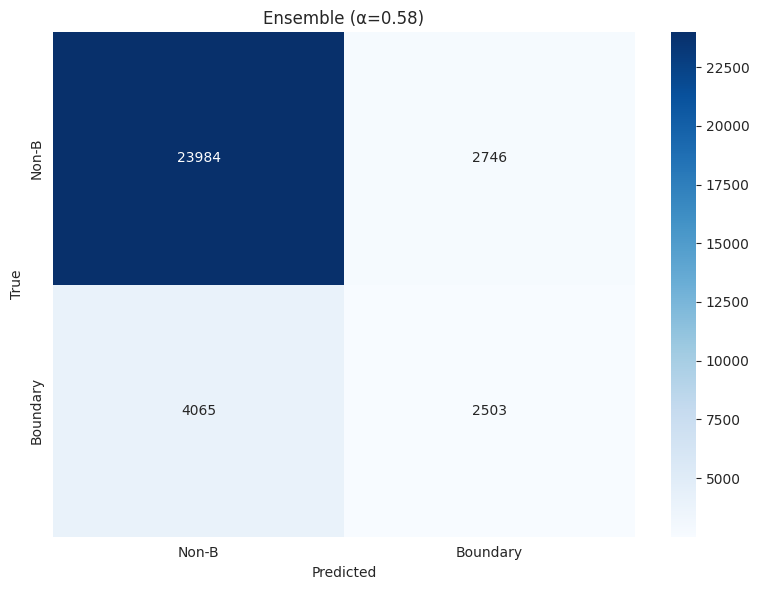

In [11]:
probs_ensemble = best_alpha * probs_deberta + (1 - best_alpha) * probs_llama
y_pred_ensemble = np.argmax(probs_ensemble, axis=1)

print("="*70)
print("ENSEMBLE FINAL")
print("="*70)
print(classification_report(y_true, y_pred_ensemble, 
                           target_names=['Non-Boundary', 'Boundary'], digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_ensemble)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Non-B', 'Boundary'],
           yticklabels=['Non-B', 'Boundary'])
plt.title(f'Ensemble (α={best_alpha:.2f})')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=300)
plt.show()

## 11. Comparación Global


EVOLUCIÓN DEL PROYECTO
            Model       F1
         Baseline 0.707000
              ICL 0.383000
       DeBERTa-FT 0.643763
         Llama-FT 0.600883
Ensemble (α=0.58) 0.649646


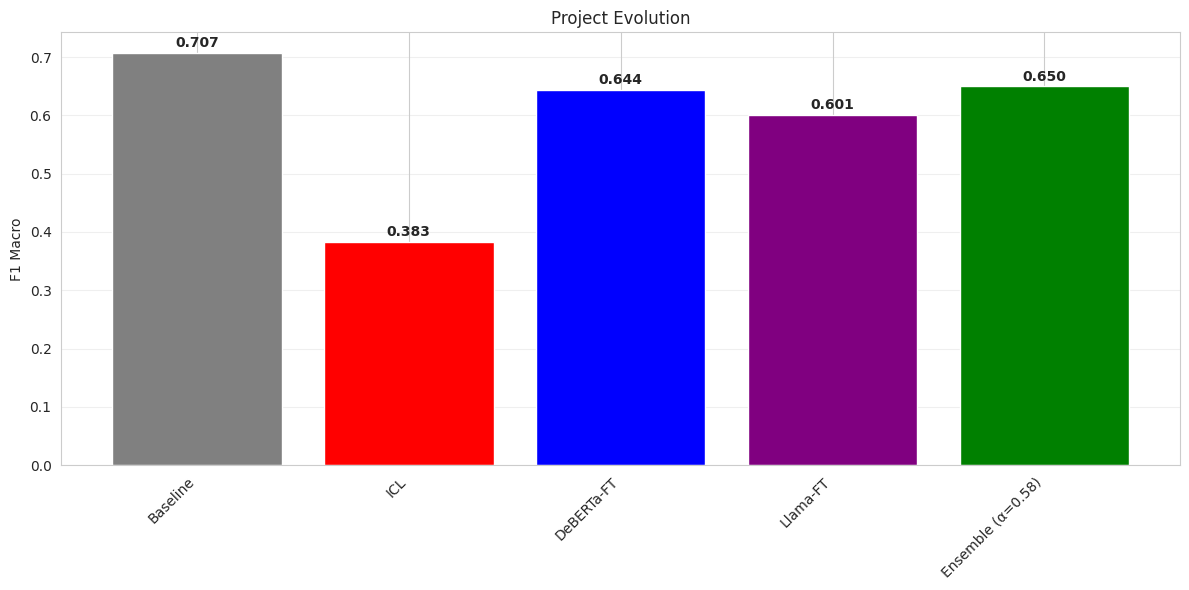


✓ Mejora total: -8.11%


In [12]:
# Load historic metrics
historic = []

# Baseline
try:
    with open(REPORTS_DIR / '09_metrics.json') as f:
        data = json.load(f)
    historic.append({'Model': 'Baseline', 'F1': data.get('f1_macro', 0.707)})
except:
    historic.append({'Model': 'Baseline', 'F1': 0.707})

# ICL
try:
    with open(REPORTS_DIR / '11_icl_metrics_final.json') as f:
        data = json.load(f)
    historic.append({'Model': 'ICL', 'F1': data.get('f1_macro', 0.383)})
except:
    historic.append({'Model': 'ICL', 'F1': 0.383})

# DeBERTa
y_pred_deb = np.argmax(probs_deberta, axis=1)
historic.append({'Model': 'DeBERTa-FT', 'F1': f1_score(y_true, y_pred_deb, average='macro')})

# Llama
y_pred_llm = np.argmax(probs_llama, axis=1)
historic.append({'Model': 'Llama-FT', 'F1': f1_score(y_true, y_pred_llm, average='macro')})

# Ensemble
historic.append({'Model': f'Ensemble (α={best_alpha:.2f})', 'F1': best_f1})

df_hist = pd.DataFrame(historic)
print("\nEVOLUCIÓN DEL PROYECTO")
print(df_hist.to_string(index=False))

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(df_hist)), df_hist['F1'], 
              color=['gray', 'red', 'blue', 'purple', 'green'])
plt.xticks(range(len(df_hist)), df_hist['Model'], rotation=45, ha='right')
plt.ylabel('F1 Macro')
plt.title('Project Evolution')
plt.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, df_hist['F1'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'global_comparison.png', dpi=300)
plt.show()

improvement = ((best_f1 - historic[0]['F1']) / historic[0]['F1']) * 100
print(f"\n✓ Mejora total: {improvement:+.2f}%")

## 12. Guardar Reporte Final

In [13]:
report = {
    'ensemble': {
        'alpha': float(best_alpha),
        'f1_macro': float(best_f1),
        'accuracy': float(accuracy_score(y_true, y_pred_ensemble))
    },
    'individual': {
        'deberta_f1': float(f1_score(y_true, y_pred_deb, average='macro')),
        'llama_f1': float(f1_score(y_true, y_pred_llm, average='macro'))
    },
    'improvement': float(improvement)
}

with open(OUTPUT_DIR / 'ensemble_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(f"\n✓ Report saved: {OUTPUT_DIR / 'ensemble_report.json'}")
print(f"\n{'='*70}")
print("EVALUACIÓN COMPLETA")
print(f"{'='*70}")
print(f"Best α: {best_alpha:.2f}")
print(f"Ensemble F1: {best_f1:.4f}")
print(f"Improvement: {improvement:+.2f}%")
print(f"{'='*70}")


✓ Report saved: /home/eeguskiza/DEUSTO/multi-author-analysis/outputs/ensemble/ensemble_report.json

EVALUACIÓN COMPLETA
Best α: 0.58
Ensemble F1: 0.6496
Improvement: -8.11%
